<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/concrete_crack_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de Grietas en Concreto con CNN + Medición de Dimensiones

Este notebook toma el dataset **Concrete Crack Images for Classification** de Kaggle
(https://www.kaggle.com/datasets/arnavr10880/concrete-crack-images-for-classification) y:

1. Descarga y organiza el dataset (clases `Positive` / `Negative`).
2. Lo divide en **train / validation / test**.
3. Construye y entrena una **CNN** para clasificar si una imagen de concreto tiene grieta o no.
4. Valida y evalúa el modelo (curvas de entrenamiento, métricas en test, matriz de confusión).
5. Para las imágenes clasificadas como **con grieta**, calcula sus **dimensiones aproximadas**
   (longitud, ancho promedio, área y bounding box) usando procesamiento de imágenes con OpenCV.

> **Nota sobre unidades:** las dimensiones se calculan en **píxeles**. Para convertirlas a unidades
> reales (mm, cm) necesitas un factor de calibración (por ejemplo, fotografiar una regla u objeto
> de tamaño conocido en las mismas condiciones de la cámara).

## 1. Instalación de dependencias

In [ ]:
!pip install -q split-folders


## 2. Descarga del dataset desde Kaggle

Necesitas tu archivo `kaggle.json` (se obtiene en tu cuenta de Kaggle: *Settings > API > Create New Token*).
Al ejecutar la celda se te pedirá subirlo.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arnavr10880/concrete-crack-images-for-classification")

print("Path to dataset files:", path)

100%|██████████| 233M/233M [00:04<00:00, 54.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arnavr10880/concrete-crack-images-for-classification/versions/1


## 3. Localizar automáticamente la carpeta con las clases

El zip suele traer subcarpetas anidadas. Esta celda busca la carpeta que contiene
directamente las dos clases (`Positive` y `Negative`).

In [ ]:
import os

In [ ]:
def encontrar_carpeta_clases(root):
    """Busca una carpeta que contenga exactamente 2 subcarpetas no vacías (las clases)."""
    for dirpath, dirnames, filenames in os.walk(root):
        if len(dirnames) == 2:
            no_vacias = all(
                len(os.listdir(os.path.join(dirpath, d))) > 0 for d in dirnames
            )
            if no_vacias:
                return dirpath, dirnames
    return None, None

dataset_root, clases = encontrar_carpeta_clases(path)
print("Carpeta con las clases:", dataset_root)
print("Clases encontradas:", clases)


Carpeta con las clases: /root/.cache/kagglehub/datasets/arnavr10880/concrete-crack-images-for-classification/versions/1
Clases encontradas: ['Positive', 'Negative']


## 4. División en train / validation / test (70% / 15% / 15%)

In [ ]:
import splitfolders

splitfolders.ratio(
    dataset_root,
    output="dataset_split",
    seed=1337,
    ratio=(0.7, 0.15, 0.15),
    group_prefix=None
)

for split in ["train", "val", "test"]:
    for c in clases:
        n = len(os.listdir(f"dataset_split/{split}/{c}"))
        print(f"{split}/{c}: {n} imágenes")


Copying files: 40000 files [00:18, 2206.74 files/s]

train/Positive: 14000 imágenes
train/Negative: 14000 imágenes
val/Positive: 3000 imágenes
val/Negative: 3000 imágenes
test/Positive: 3000 imágenes
test/Negative: 3000 imágenes


## 5. Generadores de datos (con augmentación en train)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    "dataset_split/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    "dataset_split/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    "dataset_split/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Mapeo de clases:", train_gen.class_indices)


Found 28000 images belonging to 2 classes.
Found 6000 images belonging to 2 classes.
Found 6000 images belonging to 2 classes.
Mapeo de clases: {'Negative': 0, 'Positive': 1}


## 6. Arquitectura de la CNN

In [ ]:
from tensorflow.keras import layers, models

def crear_modelo_cnn(input_shape=(128, 128, 3)):
    modelo = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')  # binario: grieta / sin grieta
    ])
    return modelo

modelo = crear_modelo_cnn()
modelo.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,339,905 (8.93 MB)

 Trainable params: 2,339,201 (8.92 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
modelo.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


## 7. Entrenamiento

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('mejor_modelo_grietas.h5', monitor='val_accuracy', save_best_only=True)
]

EPOCHS = 20

historial = modelo.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9716 - loss: 0.1702

875/875 ━━━━━━━━━━━━━━━━━━━━ 154s 166ms/step - accuracy: 0.9840 - loss: 0.0863 - val_accuracy: 0.9952 - val_loss: 0.0190
Epoch 2/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 141s 161ms/step - accuracy: 0.9923 - loss: 0.0303 - val_accuracy: 0.9875 - val_loss: 0.0616
Epoch 3/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 140s 160ms/step - accuracy: 0.9944 - loss: 0.0250 - val_accuracy: 0.9828 - val_loss: 0.0735
Epoch 4/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 141s 161ms/step - accuracy: 0.9952 - loss: 0.0188 - val_accuracy: 0.9837 - val_loss: 0.0576
Epoch 5/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 140s 160ms/step - accuracy: 0.9948 - loss: 0.0248 - val_accuracy: 0.9832 - val_loss: 0.1073
Epoch 6/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9949 - loss: 0.0211

875/875 ━━━━━━━━━━━━━━━━━━━━ 140s 161ms/step - accuracy: 0.9955 - loss: 0.0198 - val_accuracy: 0.9977 - val_loss: 0.0114
Epoch 7/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 140s 160ms/step - accuracy: 0.9950 - loss: 0.0202 - val_accuracy: 0.9915 - val_loss: 0.0377
Epoch 8/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 143s 164ms/step - accuracy: 0.9967 - loss: 0.0143 - val_accuracy: 0.9972 - val_loss: 0.0095
Epoch 9/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 142s 162ms/step - accuracy: 0.9961 - loss: 0.0175 - val_accuracy: 0.9960 - val_loss: 0.0198
Epoch 10/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 143s 163ms/step - accuracy: 0.9964 - loss: 0.0166 - val_accuracy: 0.9965 - val_loss: 0.0201
Epoch 11/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 143s 163ms/step - accuracy: 0.9965 - loss: 0.0149 - val_accuracy: 0.9977 - val_loss: 0.0132
Epoch 12/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 141s 161ms/step - accuracy: 0.9965 - loss: 0.0154 - val_accuracy: 0.9970 - val_loss: 0.0128
Epoch 13/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 140s 160ms/step - accuracy: 0.9966 - loss: 

## 8. Curvas de entrenamiento / validación

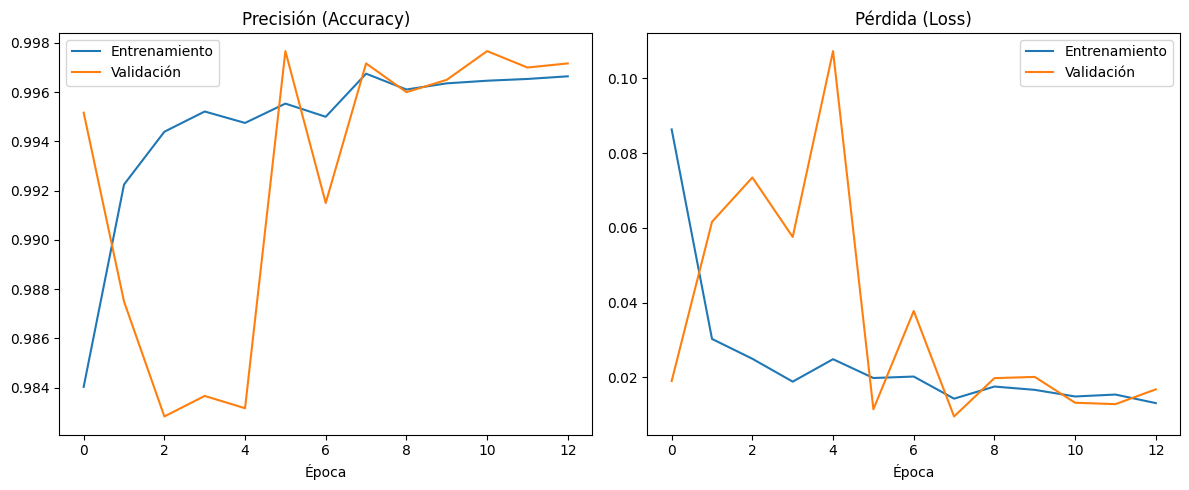

In [ ]:
import matplotlib.pyplot as plt

def graficar_historial(historial):
    acc = historial.history['accuracy']
    val_acc = historial.history['val_accuracy']
    loss = historial.history['loss']
    val_loss = historial.history['val_loss']
    rango_epocas = range(len(acc))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(rango_epocas, acc, label='Entrenamiento')
    plt.plot(rango_epocas, val_acc, label='Validación')
    plt.legend()
    plt.title('Precisión (Accuracy)')
    plt.xlabel('Época')

    plt.subplot(1, 2, 2)
    plt.plot(rango_epocas, loss, label='Entrenamiento')
    plt.plot(rango_epocas, val_loss, label='Validación')
    plt.legend()
    plt.title('Pérdida (Loss)')
    plt.xlabel('Época')

    plt.tight_layout()
    plt.show()

graficar_historial(historial)


## 9. Evaluación en el conjunto de test

188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9975 - loss: 0.0172
Precisión en test: 0.9975
Pérdida en test: 0.0172
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      3000
    Positive       1.00      1.00      1.00      3000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



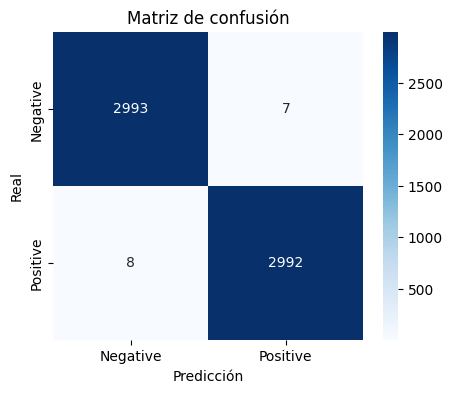

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_loss, test_acc = modelo.evaluate(test_gen)
print(f"Precisión en test: {test_acc:.4f}")
print(f"Pérdida en test: {test_loss:.4f}")

pred_probs = modelo.predict(test_gen)
pred_clases = (pred_probs > 0.5).astype(int).flatten()
clases_reales = test_gen.classes
nombres_clases = list(test_gen.class_indices.keys())

print(classification_report(clases_reales, pred_clases, target_names=nombres_clases))

matriz = confusion_matrix(clases_reales, pred_clases)
plt.figure(figsize=(5, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión')
plt.show()


Ejemplos de clasificación de la red:
----------------------------------------

Análisis de imagen 1: 06839.jpg
---------------------------
Predicción: Positive  (confianza: 100.00%)
Se detectó una grieta. Calculando dimensiones...


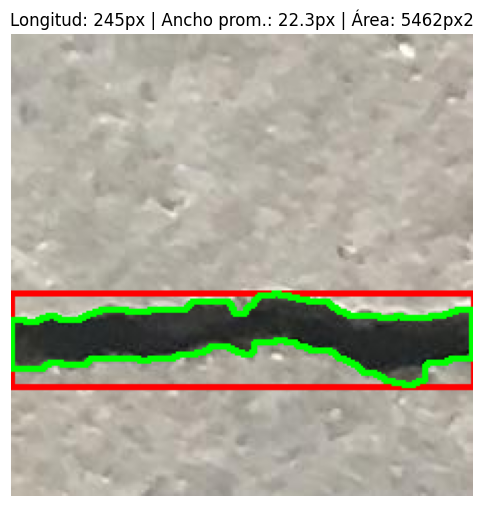

  Resultados de la grieta: Longitud: 245px, Ancho Promedio: 22.3px, Área: 5462.5px²


Análisis de imagen 2: 16021_1.jpg
-----------------------------
Predicción: Positive  (confianza: 100.00%)
Se detectó una grieta. Calculando dimensiones...


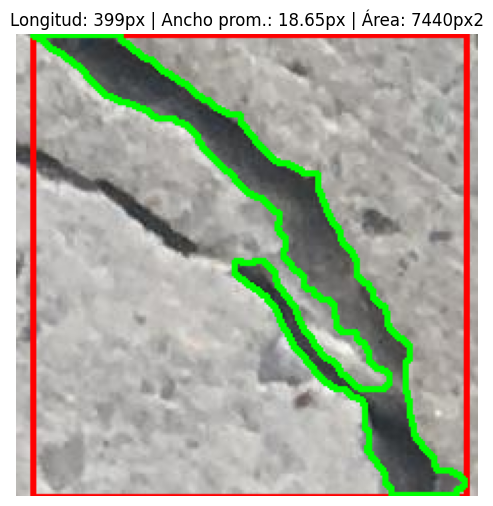

  Resultados de la grieta: Longitud: 399px, Ancho Promedio: 18.65px, Área: 7440.0px²


Análisis de imagen 3: 06451.jpg
---------------------------
Predicción: Positive  (confianza: 100.00%)
Se detectó una grieta. Calculando dimensiones...


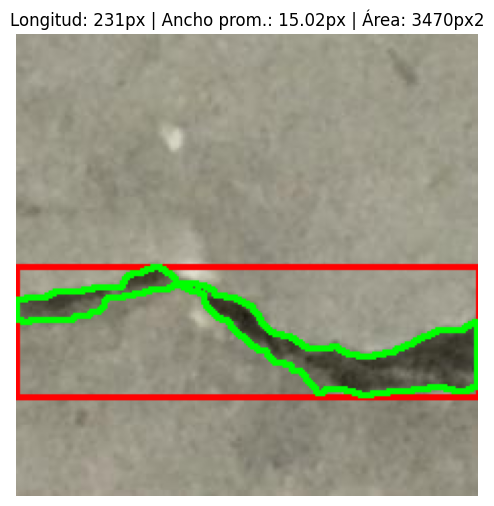

  Resultados de la grieta: Longitud: 231px, Ancho Promedio: 15.02px, Área: 3470.5px²


Análisis de imagen 4: 07256.jpg
---------------------------
Predicción: Positive  (confianza: 100.00%)
Se detectó una grieta. Calculando dimensiones...


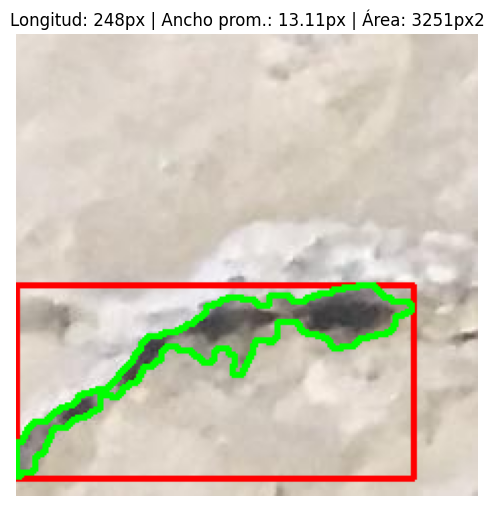

  Resultados de la grieta: Longitud: 248px, Ancho Promedio: 13.11px, Área: 3251.0px²



In [ ]:
import os
import random

# Obtener la ruta a la carpeta de imágenes positivas del conjunto de prueba
carpeta_test_positivas = os.path.join("dataset_split", "test", "Positive")
carpeta_test_negativas = os.path.join("dataset_split", "test", "Negative")

# Seleccionar 4 imágenes, intentando tener una mezcla si es posible
# Para este ejemplo, seleccionaremos 2 positivas y 2 negativas para mostrar ambos casos
ejemplos_rutas = []

# 2 imágenes positivas
archivos_positivos = os.listdir(carpeta_test_positivas)
if len(archivos_positivos) >= 2:
    ejemplos_rutas.extend(random.sample(archivos_positivos, 2))
else:
    ejemplos_rutas.extend(archivos_positivos)

# 2 imágenes negativas
archivos_negativos = os.listdir(carpeta_test_negativas)
if len(archivos_negativos) >= 2:
    ejemplos_rutas.extend(random.sample(archivos_negativos, 2))
else:
    ejemplos_rutas.extend(archivos_negativos)


print("Ejemplos de clasificación de la red:")
print("-" * 40)

for i, nombre_archivo in enumerate(ejemplos_rutas[:4]): # Asegurarse de tomar solo 4
    if nombre_archivo in archivos_positivos:
        ruta_completa = os.path.join(carpeta_test_positivas, nombre_archivo)
    else:
        ruta_completa = os.path.join(carpeta_test_negativas, nombre_archivo)

    print(f"\nAnálisis de imagen {i+1}: {nombre_archivo}")
    print("-" * (len(nombre_archivo) + 18))

    resultado = analizar_imagen(ruta_completa, modelo, train_gen.class_indices, IMG_SIZE)

    if resultado:
        # Si hay resultados de grieta, imprimirlos detalladamente
        print(f"  Resultados de la grieta: Longitud: {resultado['longitud_grieta_px']}px, "
              f"Ancho Promedio: {resultado['ancho_promedio_grieta_px']}px, "
              f"Área: {resultado['area_px2']}px²")
    else:
        print("  No se encontraron detalles de grieta (clasificada como 'Negative').")

    print("\n" + "=" * 50)

Ejemplos de clasificación de la red (solo clasificación):
--------------------------------------------------

Análisis de imagen 1: 12680_1.jpg
-----------------------------


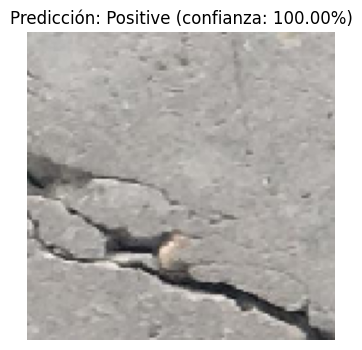



Análisis de imagen 2: 10056_1.jpg
-----------------------------


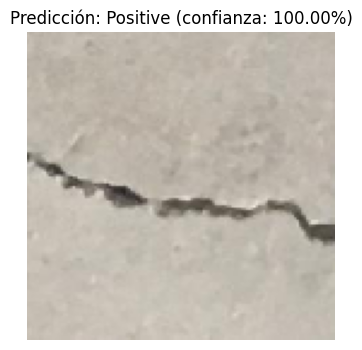



Análisis de imagen 3: 12170.jpg
---------------------------


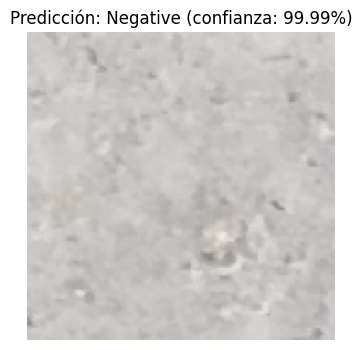



Análisis de imagen 4: 07827.jpg
---------------------------


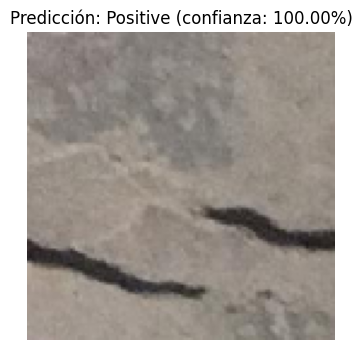

In [ ]:
import os
import random
from tensorflow.keras.preprocessing import image as kimage
import numpy as np
import matplotlib.pyplot as plt

def clasificar_imagen_sin_medir(ruta_imagen, modelo, class_indices, img_size=(128, 128)):
    """
    Clasifica la imagen con la CNN (grieta / sin grieta) sin calcular dimensiones y la muestra.
    """
    img = kimage.load_img(ruta_imagen, target_size=img_size)
    arr = kimage.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    prob = modelo.predict(arr, verbose=0)[0][0]
    clase_idx = int(prob > 0.5)
    nombre_clase = [k for k, v in class_indices.items() if v == clase_idx][0]
    confianza = prob if clase_idx == 1 else 1 - prob

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Predicción: {nombre_clase} (confianza: {confianza:.2%})")
    plt.axis('off')
    plt.show()

    # No se llama a medir_grieta aquí, como se solicitó

# Obtener la ruta a la carpeta de imágenes del conjunto de prueba
carpeta_test_positivas = os.path.join("dataset_split", "test", "Positive")
carpeta_test_negativas = os.path.join("dataset_split", "test", "Negative")

ejemplos_rutas_sin_medir = []

# 2 imágenes positivas
archivos_positivos = os.listdir(carpeta_test_positivas)
if len(archivos_positivos) >= 2:
    ejemplos_rutas_sin_medir.extend(random.sample(archivos_positivos, 2))
else:
    ejemplos_rutas_sin_medir.extend(archivos_positivos)

# 2 imágenes negativas
archivos_negativos = os.listdir(carpeta_test_negativas)
if len(archivos_negativos) >= 2:
    ejemplos_rutas_sin_medir.extend(random.sample(archivos_negativos, 2))
else:
    ejemplos_rutas_sin_medir.extend(archivos_negativos)

print("Ejemplos de clasificación de la red (solo clasificación):")
print("-" * 50)

for i, nombre_archivo in enumerate(ejemplos_rutas_sin_medir[:4]): # Asegurarse de tomar solo 4
    if nombre_archivo in archivos_positivos:
        ruta_completa = os.path.join(carpeta_test_positivas, nombre_archivo)
    else:
        ruta_completa = os.path.join(carpeta_test_negativas, nombre_archivo)

    print(f"\nAnálisis de imagen {i+1}: {nombre_archivo}")
    print("-" * (len(nombre_archivo) + 18))

    clasificar_imagen_sin_medir(ruta_completa, modelo, train_gen.class_indices, IMG_SIZE)

    print("\n" + "=" * 50)

## 10. Medición de dimensiones de la grieta

Cuando el modelo clasifica una imagen como **con grieta**, esta función:

- Binariza la imagen (Otsu invertido, ya que la grieta suele ser más oscura que el concreto).
- Limpia el ruido con operaciones morfológicas.
- Encuentra el contorno principal (la grieta).
- Calcula: bounding box (ancho/alto), área, perímetro, longitud (vía esqueletización) y ancho promedio.

Todas las medidas están en **píxeles**; para convertirlas a unidades reales multiplica por tu
factor de calibración (unidad_real / píxel).

In [ ]:
import cv2
from skimage.morphology import skeletonize

def medir_grieta(ruta_imagen, mostrar=True):
    """Detecta el contorno de una grieta y estima sus dimensiones en píxeles."""
    img = cv2.imread(ruta_imagen)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    gris_suave = cv2.GaussianBlur(gris, (5, 5), 0)
    _, binaria = cv2.threshold(gris_suave, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    kernel = np.ones((3, 3), np.uint8)
    binaria = cv2.morphologyEx(binaria, cv2.MORPH_OPEN, kernel, iterations=1)
    binaria = cv2.morphologyEx(binaria, cv2.MORPH_CLOSE, kernel, iterations=2)

    contornos, _ = cv2.findContours(binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contornos:
        print("No se detectó un contorno de grieta claro en esta imagen.")
        return None

    contorno_mayor = max(contornos, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(contorno_mayor)
    area_px = cv2.contourArea(contorno_mayor)
    perimetro_px = cv2.arcLength(contorno_mayor, True)

    mascara = np.zeros_like(binaria)
    cv2.drawContours(mascara, [contorno_mayor], -1, 255, thickness=cv2.FILLED)
    esqueleto = skeletonize(mascara > 0)
    longitud_esqueleto_px = int(np.sum(esqueleto))
    ancho_promedio_px = area_px / longitud_esqueleto_px if longitud_esqueleto_px > 0 else 0

    resultados = {
        "bbox_ancho_px": w,
        "bbox_alto_px": h,
        "area_px2": round(area_px, 2),
        "perimetro_px": round(perimetro_px, 2),
        "longitud_grieta_px": longitud_esqueleto_px,
        "ancho_promedio_grieta_px": round(ancho_promedio_px, 2),
    }

    if mostrar:
        img_anotada = img_rgb.copy()
        cv2.rectangle(img_anotada, (x, y), (x + w, y + h), (255, 0, 0), 2)
        cv2.drawContours(img_anotada, [contorno_mayor], -1, (0, 255, 0), 2)

        plt.figure(figsize=(6, 6))
        plt.imshow(img_anotada)
        plt.title(
            f"Longitud: {resultados['longitud_grieta_px']}px | "
            f"Ancho prom.: {resultados['ancho_promedio_grieta_px']}px | "
            f"Área: {int(area_px)}px2"
        )
        plt.axis('off')
        plt.show()

    return resultados


## 11. Pipeline completo: clasificar y (si aplica) medir la grieta

In [ ]:
from tensorflow.keras.preprocessing import image as kimage

def analizar_imagen(ruta_imagen, modelo, class_indices, img_size=(128, 128)):
    """
    1) Clasifica la imagen con la CNN (grieta / sin grieta).
    2) Si detecta grieta, calcula sus dimensiones aproximadas.
    """
    img = kimage.load_img(ruta_imagen, target_size=img_size)
    arr = kimage.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    prob = modelo.predict(arr, verbose=0)[0][0]
    clase_idx = int(prob > 0.5)
    nombre_clase = [k for k, v in class_indices.items() if v == clase_idx][0]
    confianza = prob if clase_idx == 1 else 1 - prob

    print(f"Predicción: {nombre_clase}  (confianza: {confianza:.2%})")

    # Ajusta esta condición según el nombre real de tu clase positiva
    if nombre_clase.lower().startswith('positive'):
        print("Se detectó una grieta. Calculando dimensiones...")
        return medir_grieta(ruta_imagen)
    else:
        print("No se detectó grieta en esta imagen.")
        return None


## 12. Demo sobre imágenes de test

Predicción: Positive  (confianza: 100.00%)
Se detectó una grieta. Calculando dimensiones...


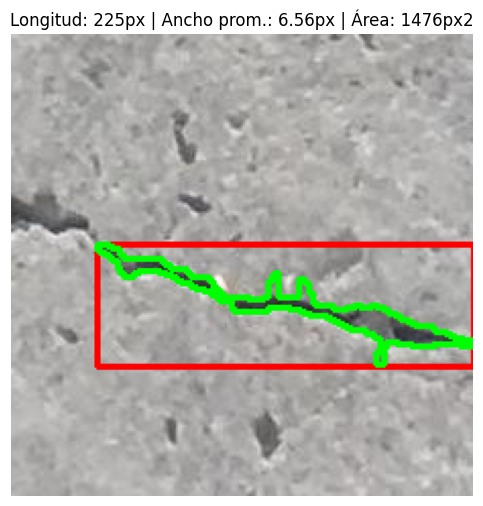

{'bbox_ancho_px': 185, 'bbox_alto_px': 60, 'area_px2': 1476.0, 'perimetro_px': 488.05, 'longitud_grieta_px': 225, 'ancho_promedio_grieta_px': 6.56}
--------------------------------------------------
Predicción: Positive  (confianza: 100.00%)
Se detectó una grieta. Calculando dimensiones...


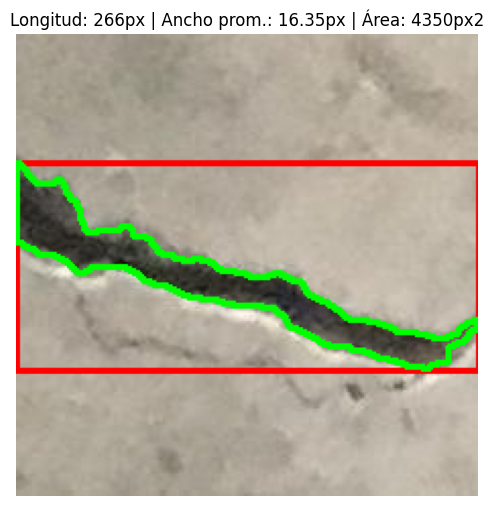

{'bbox_ancho_px': 227, 'bbox_alto_px': 102, 'area_px2': 4350.0, 'perimetro_px': 597.93, 'longitud_grieta_px': 266, 'ancho_promedio_grieta_px': 16.35}
--------------------------------------------------
Predicción: Positive  (confianza: 100.00%)
Se detectó una grieta. Calculando dimensiones...


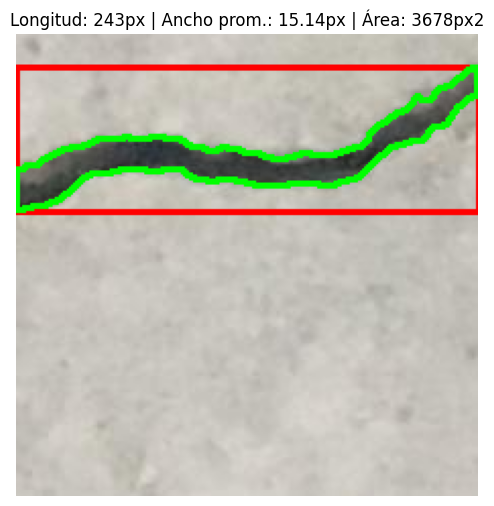

{'bbox_ancho_px': 227, 'bbox_alto_px': 71, 'area_px2': 3678.5, 'perimetro_px': 559.55, 'longitud_grieta_px': 243, 'ancho_promedio_grieta_px': 15.14}
--------------------------------------------------


In [ ]:
import random

carpeta_positivas = [c for c in clases if c.lower().startswith('positive')][0]
carpeta_test_positivas = f"dataset_split/test/{carpeta_positivas}"

ejemplos = random.sample(os.listdir(carpeta_test_positivas), min(3, len(os.listdir(carpeta_test_positivas))))
for e in ejemplos:
    ruta = os.path.join(carpeta_test_positivas, e)
    resultado = analizar_imagen(ruta, modelo, train_gen.class_indices)
    print(resultado)
    print("-" * 50)


Para revisar los resultados numéricos de las grietas detectadas, puedes inspeccionar la variable `video_analysis_results`:

COMPROBACIÓN DEL VIDEO DE ENTRADA
✅ Archivo encontrado:
/content/grietax.mp4

Tamaño del archivo:
4.39 MB

INFORMACIÓN DEL VIDEO
------------------------------------------------------------
Archivo       : grietax.mp4
Resolución    : 720 x 1280
FPS           : 16.95
Frames        : 258
Duración      : 15.22 segundos

Primer frame guardado como:
primer_frame_grietas.jpg

Mostrando el primer frame del VIDEO REAL:


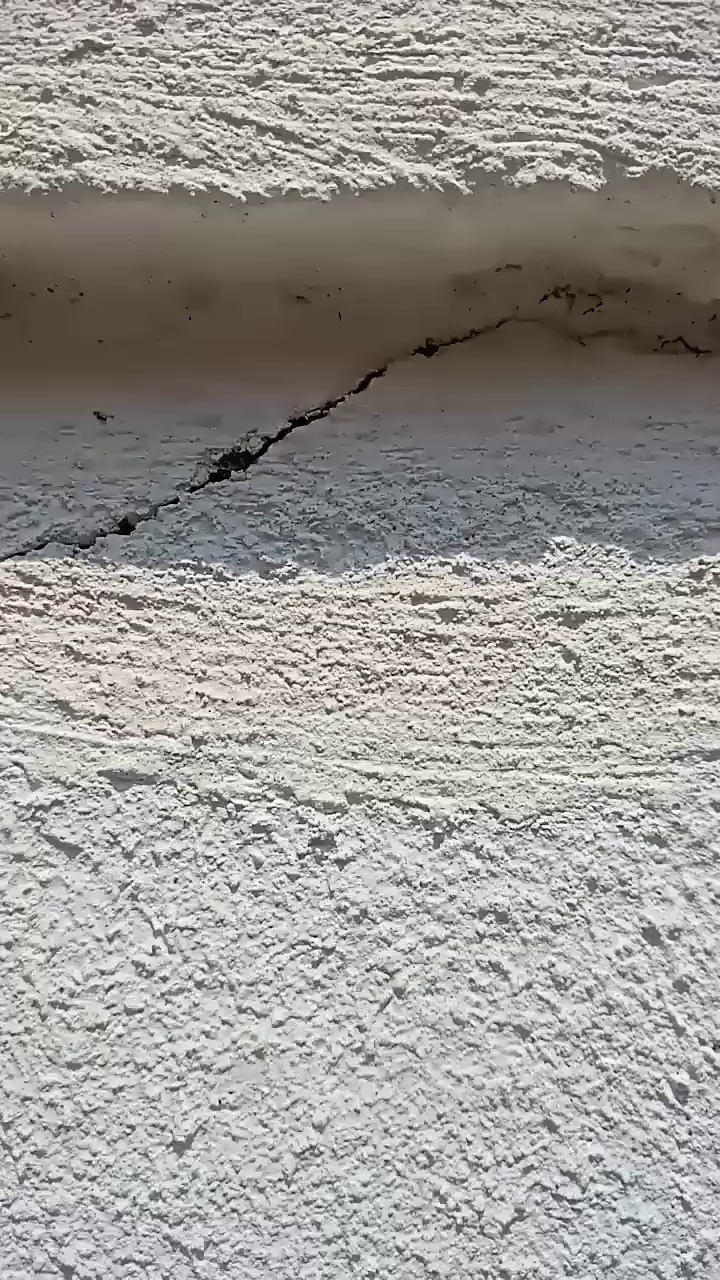


CLASES DEL MODELO
------------------------------------------------------------
{'Negative': 0, 'Positive': 1}

ÍNDICE → CLASE
0 → Negative
1 → Positive
🗑️ Eliminado CSV anterior: resultados_grietas.csv


INICIANDO ANÁLISIS
Entrada : grietax.mp4
Salida  : analisis_grietax.mp4
Frames  : 258
FPS     : 16.95
Progreso: 10% (25/258)
Progreso: 19% (50/258)
Progreso: 29% (75/258)
Progreso: 39% (100/258)
Progreso: 48% (125/258)
Progreso: 58% (150/258)
Progreso: 68% (175/258)
Progreso: 78% (200/258)
Progreso: 87% (225/258)
Progreso: 97% (250/258)


ANÁLISIS TERMINADO
Video analizado      : grietax.mp4
Frames procesados    : 256
Frames con grieta    : 255
Video resultado      : analisis_grietax.mp4
CSV resultados       : resultados_grietas.csv

ESTADÍSTICAS
------------------------------------------------------------
Longitud promedio : 6137.50 px
Longitud máxima   : 9357.00 px
Ancho promedio    : 63.71 px
Área promedio     : 381807.75 px²


ARCHIVO GENERADO CORRECTAMENTE
analisis_grietax.mp4
Ta

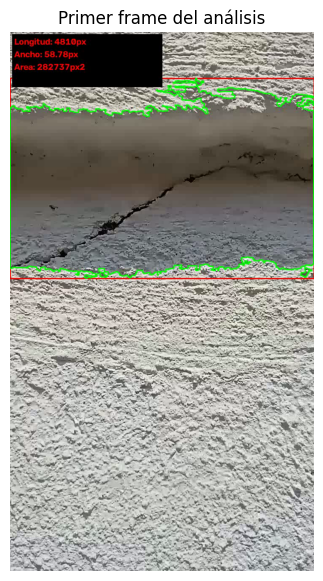


Para descargar los resultados ejecuta:
from google.colab import files
files.download('analisis_grietax.mp4')
files.download('resultados_grietas.csv')


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.morphology import skeletonize
from IPython.display import display
from PIL import Image


# ============================================================
# 1. CONFIGURACIÓN
# ============================================================

VIDEO_ENTRADA = "grietax.mp4"

VIDEO_SALIDA = "analisis_grietax.mp4"

CSV_SALIDA = "resultados_grietas.csv"

PRIMER_FRAME = "primer_frame_grietas.jpg"

# Tamaño esperado por la CNN
IMG_SIZE = (128, 128)


# ============================================================
# 2. COMPROBAR QUE EXISTE EL VIDEO REAL
# ============================================================

print("=" * 60)
print("COMPROBACIÓN DEL VIDEO DE ENTRADA")
print("=" * 60)

if not os.path.exists(VIDEO_ENTRADA):
    raise FileNotFoundError(
        f"\n❌ No se encontró: {VIDEO_ENTRADA}\n\n"
        "Sube grietas.mp4 a Colab y vuelve a ejecutar."
    )

print("✅ Archivo encontrado:")
print(os.path.abspath(VIDEO_ENTRADA))

print()
print("Tamaño del archivo:")
print(f"{os.path.getsize(VIDEO_ENTRADA) / (1024*1024):.2f} MB")


# ============================================================
# 3. ABRIR EL VIDEO REAL
# ============================================================

cap = cv2.VideoCapture(VIDEO_ENTRADA)

if not cap.isOpened():
    raise RuntimeError(
        f"No se pudo abrir el video: {VIDEO_ENTRADA}"
    )


width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fps = cap.get(cv2.CAP_PROP_FPS)

total_frames = int(
    cap.get(cv2.CAP_PROP_FRAME_COUNT)
)

if fps <= 0:
    fps = 20.0

duration = total_frames / fps if fps > 0 else 0


print("\nINFORMACIÓN DEL VIDEO")
print("-" * 60)
print(f"Archivo       : {VIDEO_ENTRADA}")
print(f"Resolución    : {width} x {height}")
print(f"FPS           : {fps:.2f}")
print(f"Frames        : {total_frames}")
print(f"Duración      : {duration:.2f} segundos")


# ============================================================
# 4. LEER Y MOSTRAR EL PRIMER FRAME
# ============================================================

ret, primer_frame = cap.read()

if not ret:
    cap.release()
    raise RuntimeError(
        "No se pudo leer el primer frame del video."
    )

cv2.imwrite(PRIMER_FRAME, primer_frame)

print("\nPrimer frame guardado como:")
print(PRIMER_FRAME)

print("\nMostrando el primer frame del VIDEO REAL:")

display(
    Image.open(PRIMER_FRAME)
)


# ============================================================
# 5. REINICIAR EL VIDEO
# ============================================================

cap.release()

cap = cv2.VideoCapture(VIDEO_ENTRADA)

if not cap.isOpened():
    raise RuntimeError(
        "No se pudo volver a abrir el video."
    )


# ============================================================
# 6. VERIFICAR EL MODELO
# ============================================================

if "modelo" not in globals():

    print("\n⚠️ No existe una variable llamada 'modelo'.")
    print("Debes cargar o entrenar tu modelo antes de continuar.")

    cap.release()

    raise RuntimeError(
        "No se encontró el modelo CNN."
    )


# ============================================================
# 7. OBTENER CLASS_INDICES
# ============================================================

if "train_gen" in globals():

    class_indices = train_gen.class_indices

elif "class_indices" in globals():

    class_indices = class_indices

else:

    cap.release()

    raise RuntimeError(
        "No se encontró 'train_gen.class_indices'.\n"
        "Define manualmente class_indices."
    )


print("\nCLASES DEL MODELO")
print("-" * 60)
print(class_indices)


# ============================================================
# 8. COMPROBAR LAS CLASES
# ============================================================

idx_to_class = {
    value: key
    for key, value in class_indices.items()
}

print("\nÍNDICE → CLASE")

for idx, nombre in idx_to_class.items():
    print(idx, "→", nombre)


# ============================================================
# 9. FUNCIÓN PARA IDENTIFICAR LA CLASE POSITIVA
# ============================================================

def es_clase_grieta(nombre_clase):

    nombre = nombre_clase.lower().strip()

    palabras_grieta = [
        "positive",
        "grieta",
        "crack",
        "fracture",
        "yes",
        "con_grieta",
        "con-grieta"
    ]

    for palabra in palabras_grieta:

        if palabra in nombre:
            return True

    return False


# ============================================================
# 10. MEDIR GRIETA
# ============================================================

def medir_grieta_from_array(
    img_array_bgr,
    mostrar=False,
    return_annotated_image=False
):

    # -----------------------------------------
    # Imagen en escala de grises
    # -----------------------------------------

    gris = cv2.cvtColor(
        img_array_bgr,
        cv2.COLOR_BGR2GRAY
    )

    # -----------------------------------------
    # Suavizado
    # -----------------------------------------

    gris_suave = cv2.GaussianBlur(
        gris,
        (5, 5),
        0
    )

    # -----------------------------------------
    # Binarización OTSU
    # -----------------------------------------

    _, binaria = cv2.threshold(
        gris_suave,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # -----------------------------------------
    # Operaciones morfológicas
    # -----------------------------------------

    kernel = np.ones(
        (3, 3),
        np.uint8
    )

    binaria = cv2.morphologyEx(
        binaria,
        cv2.MORPH_OPEN,
        kernel,
        iterations=1
    )

    binaria = cv2.morphologyEx(
        binaria,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )

    # -----------------------------------------
    # Encontrar contornos
    # -----------------------------------------

    contornos, _ = cv2.findContours(
        binaria,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # -----------------------------------------
    # Si no hay contornos
    # -----------------------------------------

    if not contornos:

        if return_annotated_image:
            return None, img_array_bgr.copy()

        return None

    # -----------------------------------------
    # El contorno de mayor área
    # -----------------------------------------

    contorno_mayor = max(
        contornos,
        key=cv2.contourArea
    )

    area_px = cv2.contourArea(
        contorno_mayor
    )

    # Evitar ruido muy pequeño
    if area_px < 20:

        if return_annotated_image:
            return None, img_array_bgr.copy()

        return None

    # -----------------------------------------
    # Bounding Box
    # -----------------------------------------

    x, y, w, h = cv2.boundingRect(
        contorno_mayor
    )

    # -----------------------------------------
    # Perímetro
    # -----------------------------------------

    perimetro_px = cv2.arcLength(
        contorno_mayor,
        True
    )

    # -----------------------------------------
    # Máscara
    # -----------------------------------------

    mascara = np.zeros_like(
        binaria
    )

    cv2.drawContours(
        mascara,
        [contorno_mayor],
        -1,
        255,
        thickness=cv2.FILLED
    )

    # -----------------------------------------
    # Skeleton
    # -----------------------------------------

    esqueleto = skeletonize(
        mascara > 0
    )

    longitud_esqueleto_px = int(
        np.sum(esqueleto)
    )

    # -----------------------------------------
    # Ancho aproximado
    # -----------------------------------------

    if longitud_esqueleto_px > 0:

        ancho_promedio_px = (
            area_px /
            longitud_esqueleto_px
        )

    else:

        ancho_promedio_px = 0

    # -----------------------------------------
    # Resultados
    # -----------------------------------------

    resultados = {

        "bbox_ancho_px": int(w),

        "bbox_alto_px": int(h),

        "area_px2": round(
            area_px,
            2
        ),

        "perimetro_px": round(
            perimetro_px,
            2
        ),

        "longitud_grieta_px":
            longitud_esqueleto_px,

        "ancho_promedio_grieta_px":
            round(
                ancho_promedio_px,
                2
            )
    }

    # -----------------------------------------
    # Imagen anotada
    # -----------------------------------------

    img_anotada = img_array_bgr.copy()

    # Rectángulo
    cv2.rectangle(
        img_anotada,
        (x, y),
        (x + w, y + h),
        (0, 0, 255),
        2
    )

    # Contorno
    cv2.drawContours(
        img_anotada,
        [contorno_mayor],
        -1,
        (0, 255, 0),
        2
    )

    # -----------------------------------------
    # Texto
    # -----------------------------------------

    font = cv2.FONT_HERSHEY_SIMPLEX

    font_scale = 0.7

    font_thickness = 2

    text_color = (0, 0, 255)

    textos = [

        f"Longitud: {longitud_esqueleto_px}px",

        f"Ancho: {ancho_promedio_px:.2f}px",

        f"Area: {int(area_px)}px2"
    ]

    # Fondo negro para texto
    box_x = 10
    box_y = 30

    box_h = 100
    box_w = 350

    cv2.rectangle(
        img_anotada,
        (box_x - 5, box_y - 25),
        (box_x + box_w, box_y + box_h),
        (0, 0, 0),
        -1
    )

    for i, texto in enumerate(textos):

        cv2.putText(
            img_anotada,
            texto,
            (
                box_x,
                box_y + i * 30
            ),
            font,
            font_scale,
            text_color,
            font_thickness,
            cv2.LINE_AA
        )

    # -----------------------------------------
    # Mostrar
    # -----------------------------------------

    if mostrar:

        plt.figure(
            figsize=(10, 6)
        )

        plt.imshow(
            cv2.cvtColor(
                img_anotada,
                cv2.COLOR_BGR2RGB
            )
        )

        plt.title(
            "Grieta detectada"
        )

        plt.axis("off")

        plt.show()

    # -----------------------------------------
    # Return
    # -----------------------------------------

    if return_annotated_image:

        return (
            resultados,
            img_anotada
        )

    return resultados


# ============================================================
# 11. ANALIZAR UN FRAME
# ============================================================

def analizar_frame(
    img_array_bgr,
    modelo,
    class_indices,
    img_size=(128, 128),
    return_annotated_image=True
):

    # -----------------------------------------
    # BGR → RGB
    # -----------------------------------------

    img_rgb = cv2.cvtColor(
        img_array_bgr,
        cv2.COLOR_BGR2RGB
    )

    # -----------------------------------------
    # Resize para CNN
    # -----------------------------------------

    input_img = cv2.resize(
        img_rgb,
        (
            img_size[1],
            img_size[0]
        )
    )

    # -----------------------------------------
    # Normalización
    # -----------------------------------------

    input_img = (
        input_img.astype(
            np.float32
        ) / 255.0
    )

    # -----------------------------------------
    # Batch
    # -----------------------------------------

    input_img = np.expand_dims(
        input_img,
        axis=0
    )

    # -----------------------------------------
    # Predicción
    # -----------------------------------------

    prob = modelo.predict(
        input_img,
        verbose=0
    )[0][0]

    # -----------------------------------------
    # Clasificación
    # -----------------------------------------

    clase_idx = int(
        prob >= 0.5
    )

    nombre_clase = idx_to_class[
        clase_idx
    ]

    # -----------------------------------------
    # Mostrar clasificación
    # -----------------------------------------

    if es_clase_grieta(
        nombre_clase
    ):

        return medir_grieta_from_array(
            img_array_bgr.copy(),
            mostrar=False,
            return_annotated_image=
                return_annotated_image
        )

    # -----------------------------------------
    # No hay grieta
    # -----------------------------------------

    if return_annotated_image:

        return (
            None,
            img_array_bgr.copy()
        )

    return None


# ============================================================
# 12. ELIMINAR RESULTADO ANTERIOR
# ============================================================

if os.path.exists(VIDEO_SALIDA):

    os.remove(
        VIDEO_SALIDA
    )

    print(
        f"\n🗑️ Eliminado video anterior: "
        f"{VIDEO_SALIDA}"
    )


if os.path.exists(CSV_SALIDA):

    os.remove(
        CSV_SALIDA
    )

    print(
        f"🗑️ Eliminado CSV anterior: "
        f"{CSV_SALIDA}"
    )


# ============================================================
# 13. ABRIR NUEVAMENTE EL VIDEO REAL
# ============================================================

cap = cv2.VideoCapture(
    VIDEO_ENTRADA
)

if not cap.isOpened():

    raise RuntimeError(
        "No se pudo abrir nuevamente "
        "grietas.mp4"
    )


# ============================================================
# 14. CONFIGURAR VIDEO DE SALIDA
# ============================================================

width = int(
    cap.get(
        cv2.CAP_PROP_FRAME_WIDTH
    )
)

height = int(
    cap.get(
        cv2.CAP_PROP_FRAME_HEIGHT
    )
)

fps = cap.get(
    cv2.CAP_PROP_FPS
)

if fps <= 0:

    fps = 20.0


fourcc = cv2.VideoWriter_fourcc(
    *"mp4v"
)

out = cv2.VideoWriter(
    VIDEO_SALIDA,
    fourcc,
    fps,
    (
        width,
        height
    )
)

if not out.isOpened():

    cap.release()

    raise RuntimeError(
        "No se pudo crear el video de salida."
    )


# ============================================================
# 15. PROCESAMIENTO FRAME POR FRAME
# ============================================================

print("\n")
print("=" * 60)
print("INICIANDO ANÁLISIS")
print("=" * 60)

print(
    f"Entrada : {VIDEO_ENTRADA}"
)

print(
    f"Salida  : {VIDEO_SALIDA}"
)

print(
    f"Frames  : {total_frames}"
)

print(
    f"FPS     : {fps:.2f}"
)

print("=" * 60)


resultados_video = []

frame_number = 0

frames_con_grieta = 0

frames_procesados = 0


while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_number += 1

    # -----------------------------------------
    # Analizar frame
    # -----------------------------------------

    resultados, frame_anotado = analizar_frame(

        frame,

        modelo,

        class_indices,

        IMG_SIZE,

        return_annotated_image=True
    )

    # -----------------------------------------
    # Hay grieta
    # -----------------------------------------

    if resultados is not None:

        frames_con_grieta += 1

        resultados_registro = {

            "frame":
                frame_number,

            "tiempo_segundos":
                frame_number / fps,

            **resultados
        }

        resultados_video.append(
            resultados_registro
        )

        out.write(
            frame_anotado
        )

    # -----------------------------------------
    # No hay grieta
    # -----------------------------------------

    else:

        out.write(
            frame
        )

    frames_procesados += 1

    # -----------------------------------------
    # Progreso
    # -----------------------------------------

    if (
        total_frames > 0
        and
        (
            frame_number %
            max(
                total_frames // 10,
                1
            )
            == 0
        )
    ):

        porcentaje = (
            frame_number /
            total_frames *
            100
        )

        print(
            f"Progreso: "
            f"{porcentaje:.0f}% "
            f"({frame_number}/"
            f"{total_frames})"
        )


# ============================================================
# 16. CERRAR VIDEO
# ============================================================

cap.release()

out.release()


# ============================================================
# 17. GUARDAR RESULTADOS CSV
# ============================================================

df = pd.DataFrame(
    resultados_video
)

if len(df) > 0:

    df.to_csv(
        CSV_SALIDA,
        index=False
    )

else:

    # Crear CSV aunque no haya detecciones
    columnas = [

        "frame",

        "tiempo_segundos",

        "bbox_ancho_px",

        "bbox_alto_px",

        "area_px2",

        "perimetro_px",

        "longitud_grieta_px",

        "ancho_promedio_grieta_px"
    ]

    df = pd.DataFrame(
        columns=columnas
    )

    df.to_csv(
        CSV_SALIDA,
        index=False
    )


# ============================================================
# 18. RESUMEN
# ============================================================

print("\n")
print("=" * 60)
print("ANÁLISIS TERMINADO")
print("=" * 60)

print(
    f"Video analizado      : {VIDEO_ENTRADA}"
)

print(
    f"Frames procesados    : {frames_procesados}"
)

print(
    f"Frames con grieta    : {frames_con_grieta}"
)

print(
    f"Video resultado      : {VIDEO_SALIDA}"
)

print(
    f"CSV resultados       : {CSV_SALIDA}"
)


# ============================================================
# 19. ESTADÍSTICAS
# ============================================================

if len(df) > 0:

    print("\nESTADÍSTICAS")
    print("-" * 60)

    print(
        f"Longitud promedio : "
        f"{df['longitud_grieta_px'].mean():.2f} px"
    )

    print(
        f"Longitud máxima   : "
        f"{df['longitud_grieta_px'].max():.2f} px"
    )

    print(
        f"Ancho promedio    : "
        f"{df['ancho_promedio_grieta_px'].mean():.2f} px"
    )

    print(
        f"Área promedio     : "
        f"{df['area_px2'].mean():.2f} px²"
    )

else:

    print(
        "\n⚠️ La CNN no detectó grietas "
        "en ningún frame."
    )


# ============================================================
# 20. VERIFICAR QUE EL VIDEO DE SALIDA EXISTE
# ============================================================

if os.path.exists(VIDEO_SALIDA):

    tamaño_salida = (
        os.path.getsize(
            VIDEO_SALIDA
        ) / (1024 * 1024)
    )

    print("\n")
    print("=" * 60)
    print("ARCHIVO GENERADO CORRECTAMENTE")
    print("=" * 60)

    print(
        f"{VIDEO_SALIDA}"
    )

    print(
        f"Tamaño: {tamaño_salida:.2f} MB"
    )

else:

    raise RuntimeError(
        "❌ No se generó el video de salida."
    )


# ============================================================
# 21. MOSTRAR PRIMER FRAME DEL RESULTADO
# ============================================================

cap_test = cv2.VideoCapture(
    VIDEO_SALIDA
)

ret, frame_resultado = cap_test.read()

cap_test.release()

if ret:

    frame_resultado_rgb = cv2.cvtColor(
        frame_resultado,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(
        figsize=(12, 7)
    )

    plt.imshow(
        frame_resultado_rgb
    )

    plt.title(
        "Primer frame del análisis"
    )

    plt.axis("off")

    plt.show()


# ============================================================
# 22. DESCARGAR DESDE COLAB
# ============================================================

print("\nPara descargar los resultados ejecuta:")

print(
    "from google.colab import files"
)

print(
    f"files.download('{VIDEO_SALIDA}')"
)

print(
    f"files.download('{CSV_SALIDA}')"
)